<a href="https://colab.research.google.com/github/vkvijaykrishna1325/Heart-Disease-Prediction-System/blob/main/HDP_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install streamlit shap pyngrok cloudflared

#  Step 1: Import Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import streamlit as st

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# Step 2: Load & Explore Dataset

In [ ]:

# Upload dataset manually in Colab before running
df = pd.read_csv("/content/heart.csv")
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 3: Data Cleaning & Preprocessing

In [ ]:

# Handle missing values if any
df = df.dropna()

# Features for doctor mode
X_doc = df.drop("target", axis=1)
y_doc = df["target"]

# Features for user mode (simulated smartwatch data)
np.random.seed(42)
df_user = pd.DataFrame({
    "age": np.random.randint(20, 80, len(df)),
    "steps": np.random.randint(1000, 15000, len(df)),
    "sleep_time": np.random.uniform(4, 10, len(df)),
    "heart_rate": np.random.randint(60, 120, len(df)),
    "target": df["target"]
})

X_user = df_user.drop("target", axis=1)
y_user = df_user["target"]


# Step 4: Train Models (User Mode & Doctor Mode)

In [ ]:

# Doctor model
X_train_doc, X_test_doc, y_train_doc, y_test_doc = train_test_split(X_doc, y_doc, test_size=0.2, random_state=42)
doc_model = RandomForestClassifier(random_state=42)
doc_model.fit(X_train_doc, y_train_doc)
y_pred_doc = doc_model.predict(X_test_doc)
print("Doctor Model Accuracy:", accuracy_score(y_test_doc, y_pred_doc))

# User model
X_train_user, X_test_user, y_train_user, y_test_user = train_test_split(X_user, y_user, test_size=0.2, random_state=42)
user_model = RandomForestClassifier(random_state=42)
user_model.fit(X_train_user, y_train_user)
y_pred_user = user_model.predict(X_test_user)
print("User Model Accuracy:", accuracy_score(y_test_user, y_pred_user))


Doctor Model Accuracy: 0.8360655737704918
User Model Accuracy: 0.5081967213114754


# Step 5: Save Models

In [ ]:

import os
os.makedirs("models", exist_ok=True)
joblib.dump(doc_model, "models/doctor_model.pkl")
joblib.dump(user_model, "models/user_model.pkl")
print("✅ Models saved in 'models/' folder")


✅ Models saved in 'models/' folder


# Step 6: Explainability with SHAP

/tmp/ipython-input-1662236582.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_doc, plot_type="bar")
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


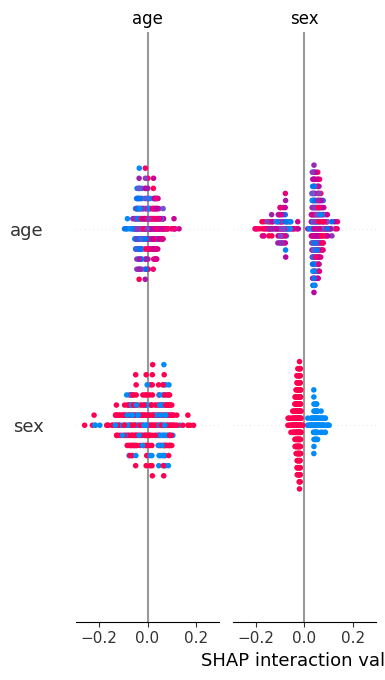

In [ ]:

explainer = shap.TreeExplainer(doc_model)
shap_values = explainer.shap_values(X_doc)

shap.summary_plot(shap_values, X_doc, plot_type="bar")


# Step 7: Create User Interface (app.py)

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd

# ------------------- Load Models -------------------
user_model = joblib.load("models/user_model.pkl")
doc_model = joblib.load("models/doctor_model.pkl")

st.set_page_config(page_title="Heart Disease Prediction", layout="wide")
st.title("Heart Disease Prediction System")

# ------------------- Sidebar Mode -------------------
mode = st.sidebar.radio("Select Mode", ["User-Friendly Mode", "Doctor-Friendly Mode"])

# ================= USER MODE =================
if mode == "User-Friendly Mode":
    st.header("User Mode: Simple Inputs (from smartwatch, etc.)")

    age=st.number_input("Age", min_value=1, max_value=120, value=45)
    steps = st.number_input("Steps Walked Today", min_value=0, max_value=50000, value=5000)
    sleep = st.number_input("Sleep Hours", min_value=0.0, max_value=24.0, value=7.0)
    heart_rate = st.number_input("Average Heart Rate", min_value=40, max_value=200, value=75)

    if st.button("Predict"):
        X_user = pd.DataFrame([[steps, sleep, heart_rate]],
                              columns=["steps", "sleep_time", "heart_rate"])
        pred = user_model.predict(X_user)[0]
        st.success(f"Prediction: {'Heart Disease Risk' if pred==1 else 'No Risk'}")

        # ------------------- User Risk Messages -------------------
        if pred==1:
          st.subheader("⚠️ Important Health Notes:")
          if steps < 5000:
              st.warning("You walked less than 5000 steps today. Try to be more active.")
          if sleep < 6:
              st.warning("Sleep is less than 6 hours. Ensure adequate rest.")
          if heart_rate < 60 or heart_rate > 100:
              st.warning("Abnormal heart rate detected. Monitor your heart rate and consult a doctor if needed.")

# ================= DOCTOR MODE =================
elif mode == "Doctor-Friendly Mode":
    st.header("Doctor Mode: Clinical Data Inputs")

    age = st.number_input("Age", min_value=1, max_value=120, value=45)

    sex = st.selectbox("Sex", ["Male (1)", "Female (0)"])

    cp = st.selectbox("Chest Pain Type (cp)", [
        "Typical Angina (0)",
        "Atypical Angina (1)",
        "Non-Anginal Pain (2)",
        "Asymptomatic (3)"
    ])

    trestbps = st.number_input("Resting Blood Pressure (trestbps)", min_value=50, max_value=250, value=120)

    chol = st.number_input("Cholesterol (mg/dl)", min_value=100, max_value=600, value=200)

    fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl (fbs)", [
        "No (0)",
        "Yes (1)"
    ])

    restecg = st.selectbox("Resting ECG", [
        "Normal (0)",
        "ST-T Abnormality (1)",
        "Left Ventricular Hypertrophy (2)"
    ])

    thalach = st.number_input("Max Heart Rate Achieved (thalach)", min_value=60, max_value=250, value=150)

    exang = st.selectbox("Exercise-Induced Angina (exang)", [
        "No (0)",
        "Yes (1)"
    ])

    oldpeak = st.number_input("ST Depression (oldpeak)", min_value=0.0, max_value=10.0, value=1.0)

    slope = st.selectbox("Slope of Peak Exercise ST", [
        "Upsloping (0)",
        "Flat (1)",
        "Downsloping (2)"
    ])

    ca = st.selectbox("Major Vessels Colored (ca)", [
        "0 – No blockage",
        "1 – 1 vessel",
        "2 – 2 vessels",
        "3 – 3 vessels",
        "4 – 4 vessels"
    ])

    thal = st.selectbox("Thalassemia (thal)", [
        "Normal (1)",
        "Fixed Defect (2)",
        "Reversible Defect (3)"
    ])

    if st.button("Predict"):

        # Convert UI labels to numeric values
        sex_value = 1 if "Male" in sex else 0
        cp_value = int(cp[-2])
        fbs_value = int(fbs[-2])
        restecg_value = int(restecg[-2])
        exang_value = int(exang[-2])
        slope_value = int(slope[-2])
        thal_value = int(thal[-2])
        ca_value = int(ca[0])

        X_doc = pd.DataFrame([[
            age, sex_value, cp_value, trestbps, chol, fbs_value, restecg_value,
            thalach, exang_value, oldpeak, slope_value, ca_value, thal_value
        ]], columns=[
            "age","sex","cp","trestbps","chol","fbs","restecg",
            "thalach","exang","oldpeak","slope","ca","thal"
        ])

        pred = doc_model.predict(X_doc)[0]

        st.success(f"Prediction: {'Heart Disease Risk' if pred==1 else 'No Risk'}")



        # ------------------- Risk Parameter Messages -------------------
        if pred==1:
          st.subheader("⚠️ Important Parameters:")

          # ---- IMPORTANT PARAMETER WARNINGS ----
          warnings = []

          if chol > 240:
              warnings.append("High Cholesterol – Risk increases.")

          if trestbps > 140:
              warnings.append("High Blood Pressure – Above normal range.")

          if fbs_value == 1:
              warnings.append("High Fasting Blood Sugar – Possible diabetes risk.")

          if exang_value == 1:
              warnings.append("Exercise-Induced Angina – Significant risk indicator.")

          if oldpeak > 2.0:
              warnings.append("Severe ST Depression (oldpeak) – High heart stress.")

          if ca_value > 0:
              warnings.append("Blockage in major vessels detected.")

          if thal_value == 2:
              warnings.append("Reversible Defect (Thal) – Higher risk level.")

          # Show warnings
          if warnings:
              st.error("⚠️ Important Parameters:")
              for w in warnings:
                  st.write("• " + w)
          else:
              st.success("No critical parameters detected.")



Writing app.py


# Step 8: Deployment with Cloudflared

In [ ]:
# Step 8: Deploy Streamlit App with Cloudflared

# Install Cloudflared
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

# Run Streamlit app in background
!streamlit run app.py --server.port 8501 &>/content/logs.txt &

# Expose app using Cloudflare tunnel
!cloudflared tunnel --url http://localhost:8501 --no-autoupdate


Selecting previously unselected package cloudflared.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2025.11.1) ...
Setting up cloudflared (2025.11.1) ...
Processing triggers for man-db (2.10.2-1) ...
2025-11-26T06:22:47Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-11-26T06:22:47Z INF Requesting new quick Tunnel on trycloudflare.com...
2025-11-26T06:22:51Z